In [1]:
import sys, os
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
os.makedirs('data/graficas', exist_ok=True)

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

2026-05-13 16:06:17.070 
  command:

    streamlit run /usr/local/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas  2.2.3
   numpy   1.26.4
   seaborn 0.13.2


In [2]:
QUERY = """
SELECT score, favorites
FROM anime
WHERE score     IS NOT NULL
  AND favorites IS NOT NULL
ORDER BY rank
"""

df = pd.read_sql(QUERY, engine)
df.rename(columns={'favorites': 'Favorites', 'score': 'Score'}, inplace=True)

print(f"✅ Datos cargados desde Supabase")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Valores nulos:")
print(df.isnull().sum())
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados desde Supabase
   Filas    : 500
   Columnas : 2

📋 Valores nulos:
Score        0
Favorites    0
dtype: int64

📋 Primeras filas:


,Score,Favorites
0,9.28,85781
1,9.16,5418
2,9.11,240854
3,9.09,12022
4,9.07,201123


In [3]:
X = df[['Favorites']].values
y = df['Score'].values

print(f"X shape: {X.shape}  (variable predictora: Favorites)")
print(f"y shape: {y.shape}  (variable objetivo:   Score)")
print(f"\n📊 Estadísticas descriptivas:")
print(df.describe().round(3))

X shape: (500, 1)  (variable predictora: Favorites)
y shape: (500,)  (variable objetivo:   Score)

📊 Estadísticas descriptivas:
         Score   Favorites
count  500.000     500.000
mean     8.429   13809.398
std      0.223   29488.870
min      8.160      24.000
25%      8.250     852.000
50%      8.370    3450.000
75%      8.562   13552.750
max      9.280  249188.000


In [4]:
resultados_globales = []

def evaluar_split(X, y, test_size, split_label, resultados_globales):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    residuos = y_test - y_pred

    pct_train = int((1 - test_size) * 100)
    pct_test  = int(test_size * 100)

    print(f"\n{'='*58}")
    print(f"  {split_label} — {pct_train}% Train / {pct_test}% Test")
    print(f"{'='*58}")
    print(f"  Train: {len(X_train):,} muestras  |  Test: {len(X_test):,} muestras")
    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  R²   (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"       → el modelo explica el {r2*100:.1f}% de la varianza del Score.")
    print(f"  MSE  (Error Cuadrático Med): {mse:.4f}")
    print(f"       → Penaliza errores grandes; sensible a outliers.")
    print(f"  RMSE (Raíz del MSE)        : {rmse:.4f}")
    print(f"       → Error promedio en puntos de Score.")
    print(f"  MAE  (Error Absoluto Med)  : {mae:.4f}")
    print(f"       → Desviación promedio absoluta de las predicciones.")

    resultados_globales.append({
        'Split': split_label, 'Train': len(X_train), 'Test': len(X_test),
        'R²': round(r2, 4), 'MSE': round(mse, 4),
        'RMSE': round(rmse, 4), 'MAE': round(mae, 4)
    })

    # ── Gráficas ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Árbol de Decisión — Regresión Score Anime\n{split_label}',
                 fontsize=14, fontweight='bold')

    # Scatter: predicciones vs reales
    axes[0].scatter(y_test, y_pred, alpha=0.35, s=15, color='#4ecdc4', label='Predicciones')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val],
                 color='#ff6b6b', lw=2, linestyle='--', label='Predicción perfecta')
    axes[0].set_xlabel('Score Real')
    axes[0].set_ylabel('Score Predicho')
    axes[0].set_title(f'Predicciones vs Reales  (R²={r2:.4f})', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Residuos
    axes[1].scatter(y_pred, residuos, alpha=0.35, s=15, color='#f7b731')
    axes[1].axhline(0, color='#ff6b6b', lw=2, linestyle='--')
    lowess = sm.nonparametric.lowess(residuos, y_pred, frac=0.3)
    axes[1].plot(lowess[:, 0], lowess[:, 1], color='#2a5298', lw=2, label='LOWESS')
    axes[1].set_xlabel('Score Predicho (ŷ)')
    axes[1].set_ylabel('Residuos')
    axes[1].set_title('Residuos vs Valores Predichos', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f"data/graficas/dt_reg_{split_label.replace(' ', '_').replace('/', '-')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred


  Split 1 (80/20) — 80% Train / 20% Test
  Train: 400 muestras  |  Test: 100 muestras

  📊 MÉTRICAS (Split 1 (80/20))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : -0.3938  (-39.38%)
       → el modelo explica el -39.4% de la varianza del Score.
  MSE  (Error Cuadrático Med): 0.0885
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.2975
       → Error promedio en puntos de Score.
  MAE  (Error Absoluto Med)  : 0.2282
       → Desviación promedio absoluta de las predicciones.


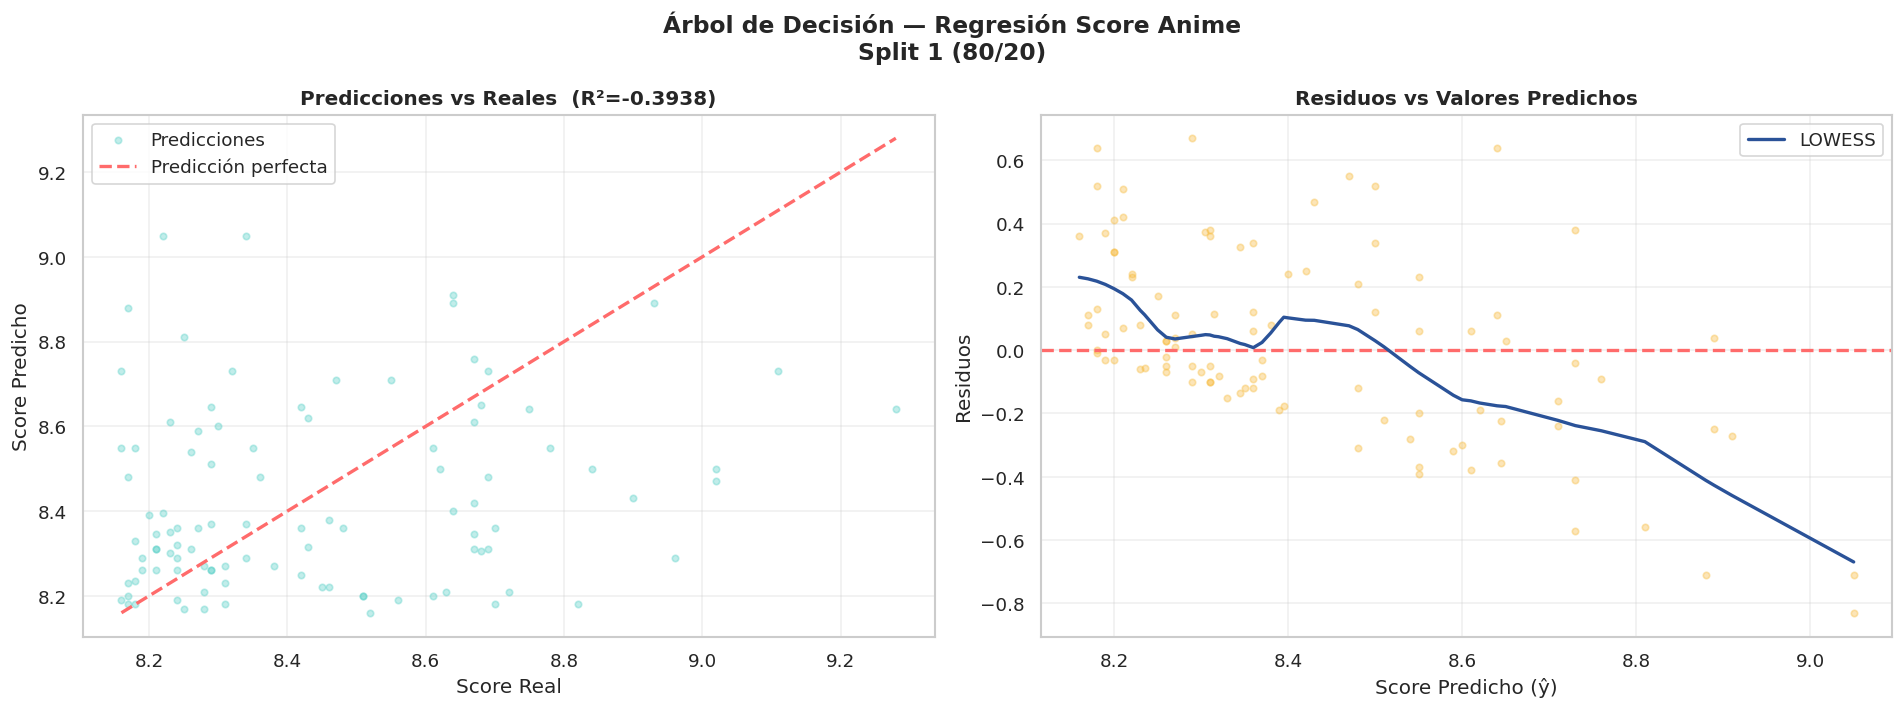

  💾 Gráfico guardado → data/graficas/dt_reg_Split_1_(80-20).png


In [5]:
modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X, y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)


  Split 2 (70/30) — 70% Train / 30% Test
  Train: 350 muestras  |  Test: 150 muestras

  📊 MÉTRICAS (Split 2 (70/30))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : -0.5658  (-56.58%)
       → el modelo explica el -56.6% de la varianza del Score.
  MSE  (Error Cuadrático Med): 0.0906
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.3010
       → Error promedio en puntos de Score.
  MAE  (Error Absoluto Med)  : 0.2358
       → Desviación promedio absoluta de las predicciones.


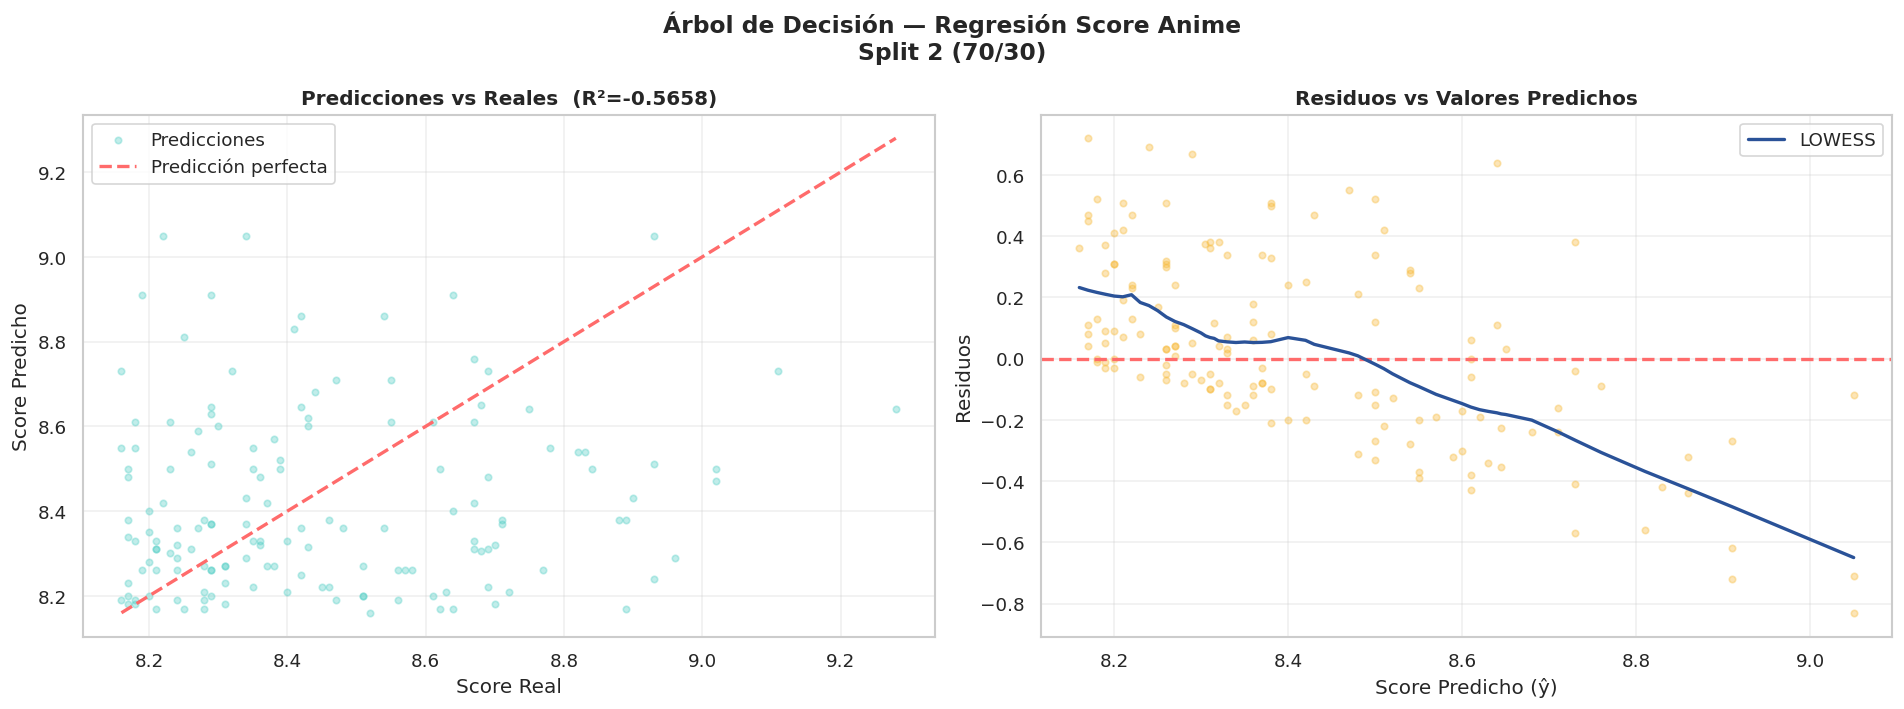

  💾 Gráfico guardado → data/graficas/dt_reg_Split_2_(70-30).png


In [6]:
modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X, y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales,
)


  Split 3 (60/40) — 60% Train / 40% Test
  Train: 300 muestras  |  Test: 200 muestras

  📊 MÉTRICAS (Split 3 (60/40))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : -0.6719  (-67.19%)
       → el modelo explica el -67.2% de la varianza del Score.
  MSE  (Error Cuadrático Med): 0.0994
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 0.3153
       → Error promedio en puntos de Score.
  MAE  (Error Absoluto Med)  : 0.2437
       → Desviación promedio absoluta de las predicciones.


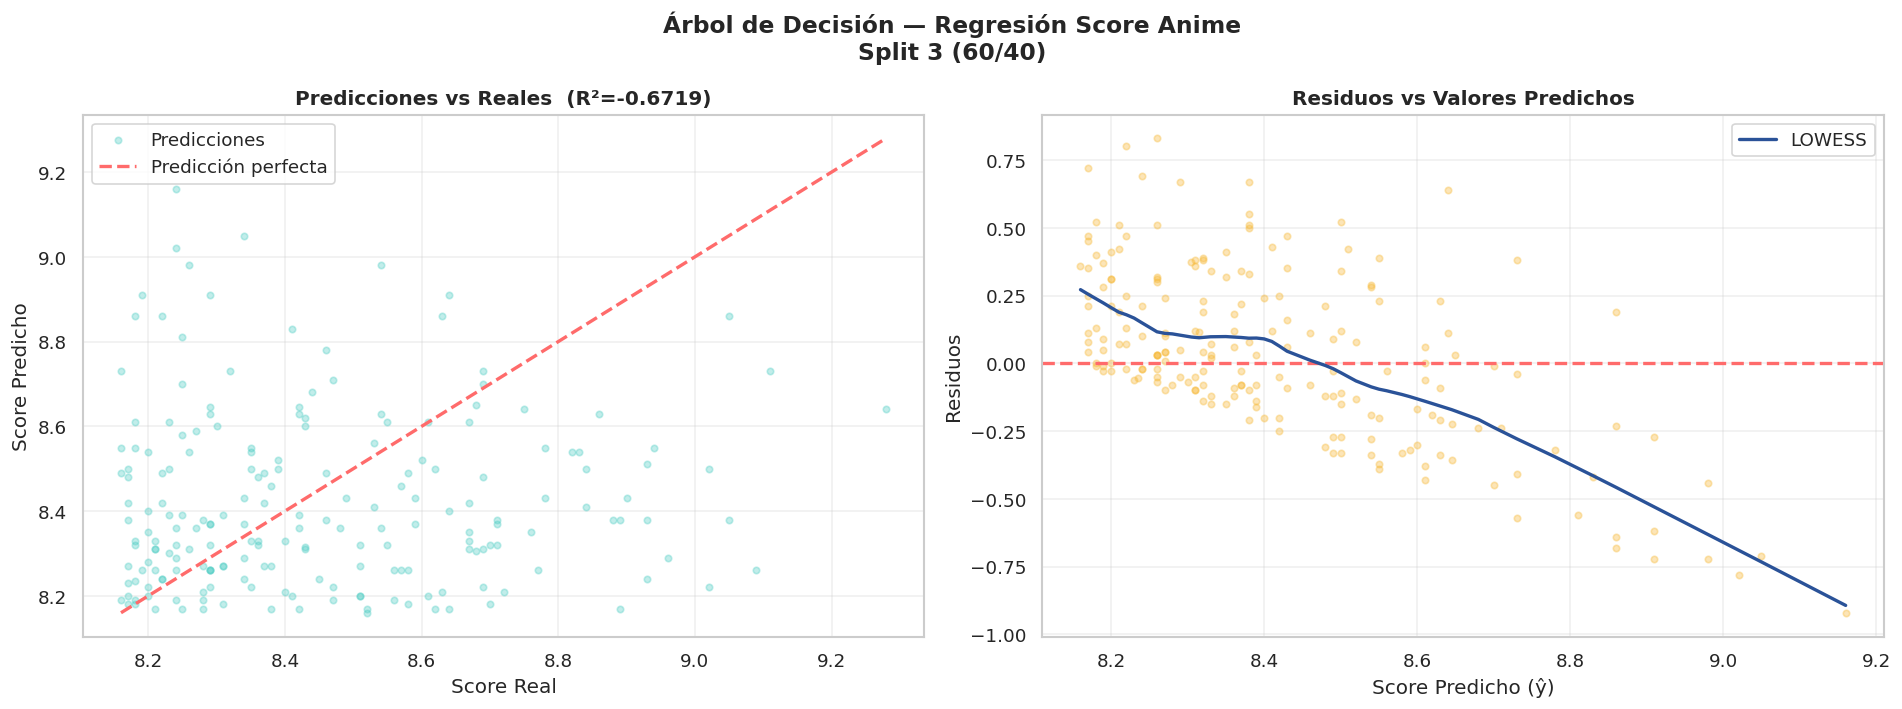

  💾 Gráfico guardado → data/graficas/dt_reg_Split_3_(60-40).png


In [7]:
modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X, y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales,
)


  TABLA COMPARATIVA — ÁRBOL DE DECISIÓN REGRESIÓN (Score Anime)
          Split  Train  Test      R²    MSE   RMSE    MAE
Split 1 (80/20)    400   100 -0.3938 0.0885 0.2975 0.2282
Split 2 (70/30)    350   150 -0.5658 0.0906 0.3010 0.2358
Split 3 (60/40)    300   200 -0.6719 0.0994 0.3153 0.2437


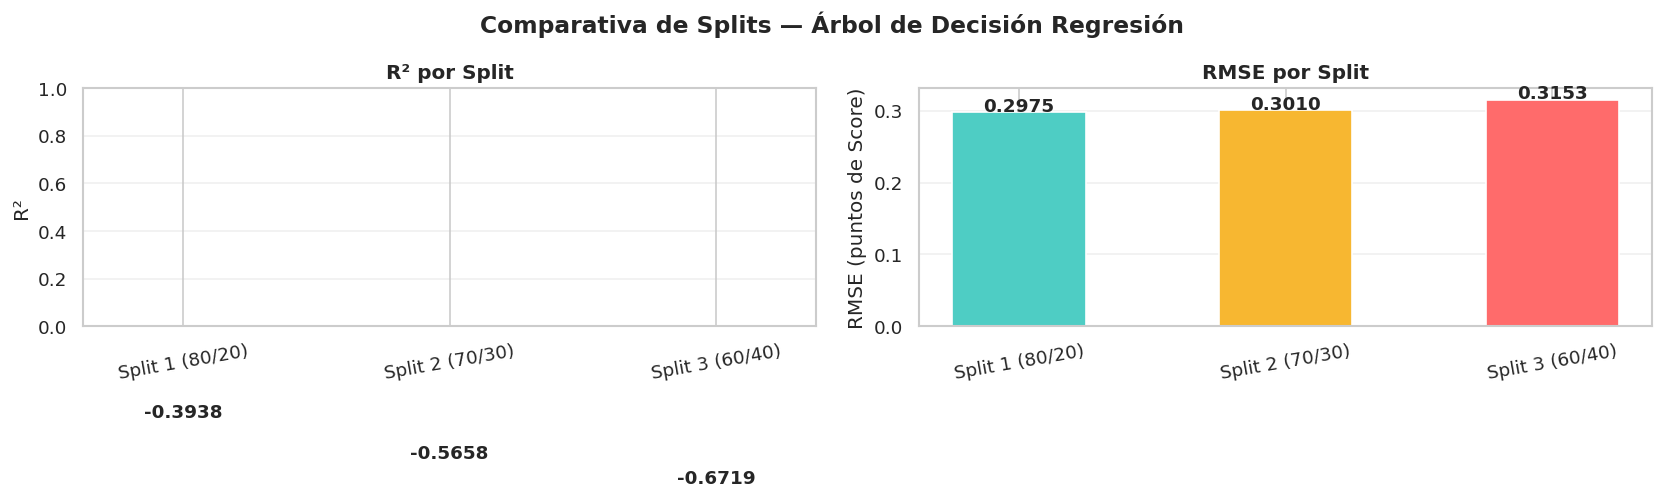


1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
   R²   máx=-0.3938  mín=-0.6719  rango=0.2781
   RMSE máx=0.3153  mín=0.2975

   ⚠️  El R² varía notablemente entre splits (variación ≥ 0.05).
      Señal de posible overfitting — considerar max_depth o min_samples_leaf.

2. MEJOR SPLIT
   Split 1 (80/20)  →  R²=-0.3938, RMSE=0.2975

3. RECOMENDACIÓN
   A) Regularizar el árbol: DecisionTreeRegressor(max_depth=4, min_samples_leaf=20)
   B) Validación cruzada (cross_val_score) para estimación más robusta del R²
   C) Comparar con RandomForestRegressor que promedía múltiples árboles
   D) El R² bajo (~13%) confirma lo del análisis de regresión lineal:
      el score de anime depende de factores cualitativos no capturables solo con favorites



In [8]:
df_resumen = pd.DataFrame(resultados_globales)

print("\n" + "="*70)
print("  TABLA COMPARATIVA — ÁRBOL DE DECISIÓN REGRESIÓN (Score Anime)")
print("="*70)
print(df_resumen.to_string(index=False))
print("="*70)

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparativa de Splits — Árbol de Decisión Regresión',
             fontsize=14, fontweight='bold')

splits = df_resumen['Split']
x = np.arange(len(splits))

axes[0].bar(x, df_resumen['R²'], color=['#4ecdc4', '#f7b731', '#ff6b6b'], width=0.5, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(splits, rotation=10)
axes[0].set_ylabel('R²'); axes[0].set_title('R² por Split', fontweight='bold')
axes[0].set_ylim(0, 1); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_resumen['R²']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(x, df_resumen['RMSE'], color=['#4ecdc4', '#f7b731', '#ff6b6b'], width=0.5, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(splits, rotation=10)
axes[1].set_ylabel('RMSE (puntos de Score)')
axes[1].set_title('RMSE por Split', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_resumen['RMSE']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/graficas/dt_reg_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis
r2_vals   = df_resumen['R²'].values
rmse_vals = df_resumen['RMSE'].values
r2_rango  = r2_vals.max() - r2_vals.min()
best      = df_resumen.loc[df_resumen['R²'].idxmax()]

print(f"\n1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS")
print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  rango={r2_rango:.4f}")
print(f"   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}")

if r2_rango < 0.05:
    print("\n   ✅ El R² es estable en los tres splits (variación < 0.05).")
    print("      El árbol generaliza bien sin depender del tamaño del split.")
else:
    print("\n   ⚠️  El R² varía notablemente entre splits (variación ≥ 0.05).")
    print("      Señal de posible overfitting — considerar max_depth o min_samples_leaf.")

print(f"\n2. MEJOR SPLIT")
print(f"   {best['Split']}  →  R²={best['R²']:.4f}, RMSE={best['RMSE']:.4f}")

print("""
3. RECOMENDACIÓN
   A) Regularizar el árbol: DecisionTreeRegressor(max_depth=4, min_samples_leaf=20)
   B) Validación cruzada (cross_val_score) para estimación más robusta del R²
   C) Comparar con RandomForestRegressor que promedía múltiples árboles
   D) El R² bajo (~13%) confirma lo del análisis de regresión lineal:
      el score de anime depende de factores cualitativos no capturables solo con favorites
""")